## **Importing packages and functions**

In [1]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import sys

#importing the necessary functions
sys.path.append("/nird/home/chrikap/Atmosphere_Ocean_Interactions_PhD/functions/nird_functions")
from common_NIRD_functions import *
from ocean_functions import*

/nird/home/chrikap/.conda/envs/nird_heat_transport/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


# **A. NorESM2-LM**

In [2]:
num_y = 500

experiments = ['piControl', 'abrupt-4xCO2']

tos_exp_noresm2 = []

for experiment in experiments:
            
    folder_path = f'/projects/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/{experiment}/r1i1p1f1/Omon/tos/gn/latest'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 12}) for file_name in file_names if file_name.endswith('.nc')]
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, num_y*12))

    yearly_tos = yearly_avg_nan_proof(ds)
    
    tos_exp_noresm2.append(yearly_tos)

In [3]:
tos_pi_renamed_noresm2 = consistent_naming(tos_exp_noresm2[0])
tos_x4_renamed_noresm2 = consistent_naming(tos_exp_noresm2[1])

tos_pi_regr_noresm2 = regrid_ocean(tos_pi_renamed_noresm2, "tos", None)
tos_x4_regr_noresm2 = regrid_ocean(tos_x4_renamed_noresm2, "tos", None)

In regrid_file
Regridding maker made


/nird/home/chrikap/.conda/envs/nird_heat_transport/lib/python3.12/site-packages/xesmf/frontend.py:718: UserWarning: Using dimensions ('j', 'i') from data variable tos as the horizontal dimensions for the regridding.
  warnings.warn(


Regridding completed
In regrid_file
Regridding maker made
Regridding completed


/nird/home/chrikap/.conda/envs/nird_heat_transport/lib/python3.12/site-packages/xesmf/frontend.py:718: UserWarning: Using dimensions ('j', 'i') from data variable tos as the horizontal dimensions for the regridding.
  warnings.warn(


In [4]:
tos_pi_regr_noresm2 = tos_pi_regr_noresm2.where(tos_pi_regr_noresm2 != 0)
tos_x4_regr_noresm2 = tos_x4_regr_noresm2.where(tos_x4_regr_noresm2 != 0)

tos_noresm2_0_30 = (tos_x4_regr_noresm2.isel(year = slice(0, 30))).mean(dim='year')['tos']
tos_noresm2_120_150 = (tos_x4_regr_noresm2.isel(year = slice(120, 150))).mean(dim='year')['tos']
tos_noresm2_470_500 = (tos_x4_regr_noresm2.isel(year = slice(470,500))).mean(dim='year')['tos']

tos_noresm2_piControl = (tos_pi_regr_noresm2.isel(year = slice(0, 30))).mean(dim='year')['tos']

# **B. IPSL-CM6A-LR**

In [7]:
experiments = ['piControl', 'abrupt-4xCO2']

tos_exp_ipsl = []

for experiment in experiments:
            
    folder_path = f'/datalake/NS9560K/ESGF/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/{experiment}/r1i1p1f1/Omon/tos/gn/latest' 

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 12}) for file_name in file_names if file_name.endswith('.nc')]
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 900*12))
    ds['time'] = to_cftime(ds['time'].values)

    yearly_tos = yearly_avg_nan_proof(ds)
    
    tos_exp_ipsl.append(yearly_tos)

/nird/home/chrikap/.conda/envs/nird_heat_transport/lib/python3.12/site-packages/xarray/coding/times.py:1133: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/nird/home/chrikap/.conda/envs/nird_heat_transport/lib/python3.12/site-packages/xarray/core/indexing.py:509: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  return np.asarray(self.get_duck_array(), dtype=dtype, copy=copy)
/nird/home/chrikap/.conda/envs/nird_heat_transport/lib/python3.12/site-packages/xarray/coding/times.py:1133: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, un

In [8]:
tos_pi_renamed_ipsl = consistent_naming(tos_exp_ipsl[0])
tos_x4_renamed_ipsl = consistent_naming(tos_exp_ipsl[1])

tos_pi_regr_ipsl = regrid_ocean(tos_pi_renamed_ipsl, "tos", None)
tos_x4_regr_ipsl = regrid_ocean(tos_x4_renamed_ipsl, "tos", None)

In regrid_file
Regridding maker made
Regridding completed
In regrid_file


/nird/home/chrikap/.conda/envs/nird_heat_transport/lib/python3.12/site-packages/xesmf/frontend.py:718: UserWarning: Using dimensions ('j', 'i') from data variable tos as the horizontal dimensions for the regridding.
  warnings.warn(


Regridding maker made
Regridding completed


/nird/home/chrikap/.conda/envs/nird_heat_transport/lib/python3.12/site-packages/xesmf/frontend.py:718: UserWarning: Using dimensions ('j', 'i') from data variable tos as the horizontal dimensions for the regridding.
  warnings.warn(


In [9]:
tos_pi_regr_ipsl = tos_pi_regr_ipsl.where(tos_pi_regr_ipsl != 0)
tos_x4_regr_ipsl = tos_x4_regr_ipsl.where(tos_x4_regr_ipsl != 0)

tos_ipsl_120_150 = (tos_x4_regr_ipsl.isel(year = slice(120, 150))).mean(dim='year')['tos']
tos_ipsl_470_500 = (tos_x4_regr_ipsl.isel(year = slice(470,500))).mean(dim='year')['tos']
tos_ipsl_870_900 = (tos_x4_regr_ipsl.isel(year = slice(870,900))).mean(dim='year')['tos']

tos_ipsl_piControl = (tos_pi_regr_ipsl.isel(year = slice(0, 30))).mean(dim='year')['tos']

# **C. CESM2**

In [10]:
experiments = ['piControl', 'abrupt-4xCO2']

tos_exp_cesm2 = []

for experiment in experiments:
            
    folder_path = f'/datalake/NS9560K/ESGF/CMIP6/CMIP/NCAR/CESM2/{experiment}/r1i1p1f1/Omon/tos/gn/latest' 

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 12}) for file_name in file_names if file_name.endswith('.nc')]
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 999*12))

    yearly_tos = yearly_avg_nan_proof(ds)
    
    tos_exp_cesm2.append(yearly_tos)

/nird/home/chrikap/.conda/envs/nird_heat_transport/lib/python3.12/site-packages/xarray/conventions.py:193: SerializationWarning: variable 'tos' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/nird/home/chrikap/.conda/envs/nird_heat_transport/lib/python3.12/site-packages/xarray/conventions.py:193: SerializationWarning: variable 'tos' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/nird/home/chrikap/.conda/envs/nird_heat_transport/lib/python3.12/site-packages/xarray/conventions.py:193: SerializationWarning: variable 'tos' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/nird/home/chrikap/.conda/envs/nird_heat_transport/lib/python3.12/site-packages/xarray/conventions.py:193: SerializationWarning: variable 'tos' has multip

In [11]:
tos_pi_renamed_cesm2 = consistent_naming(tos_exp_cesm2[0])
tos_x4_renamed_cesm2 = consistent_naming(tos_exp_cesm2[1])

tos_pi_regr_cesm2 = regrid_ocean(tos_pi_renamed_cesm2, "tos", None)
tos_x4_regr_cesm2 = regrid_ocean(tos_x4_renamed_cesm2, "tos", None)

In regrid_file
Regridding maker made
Regridding completed
In regrid_file


/nird/home/chrikap/.conda/envs/nird_heat_transport/lib/python3.12/site-packages/xesmf/frontend.py:718: UserWarning: Using dimensions ('i', 'j') from data variable tos as the horizontal dimensions for the regridding.
  warnings.warn(


Regridding maker made
Regridding completed


/nird/home/chrikap/.conda/envs/nird_heat_transport/lib/python3.12/site-packages/xesmf/frontend.py:718: UserWarning: Using dimensions ('i', 'j') from data variable tos as the horizontal dimensions for the regridding.
  warnings.warn(


In [12]:
tos_pi_regr_cesm2 = tos_pi_regr_cesm2.where(tos_pi_regr_cesm2 != 0)
tos_x4_regr_cesm2 = tos_x4_regr_cesm2.where(tos_x4_regr_cesm2 != 0)

tos_cesm2_120_150 = (tos_x4_regr_cesm2.isel(year = slice(120, 150))).mean(dim='year')['tos']
tos_cesm2_470_500 = (tos_x4_regr_cesm2.isel(year = slice(470,500))).mean(dim='year')['tos']
tos_cesm2_870_900 = (tos_x4_regr_cesm2.isel(year = slice(870,900))).mean(dim='year')['tos']
tos_cesm2_970_999 = (tos_x4_regr_cesm2.isel(year = slice(970,999))).mean(dim='year')['tos']

tos_cesm2_piControl = (tos_pi_regr_cesm2.isel(year = slice(0, 30))).mean(dim='year')['tos']

# **D. Plotting**

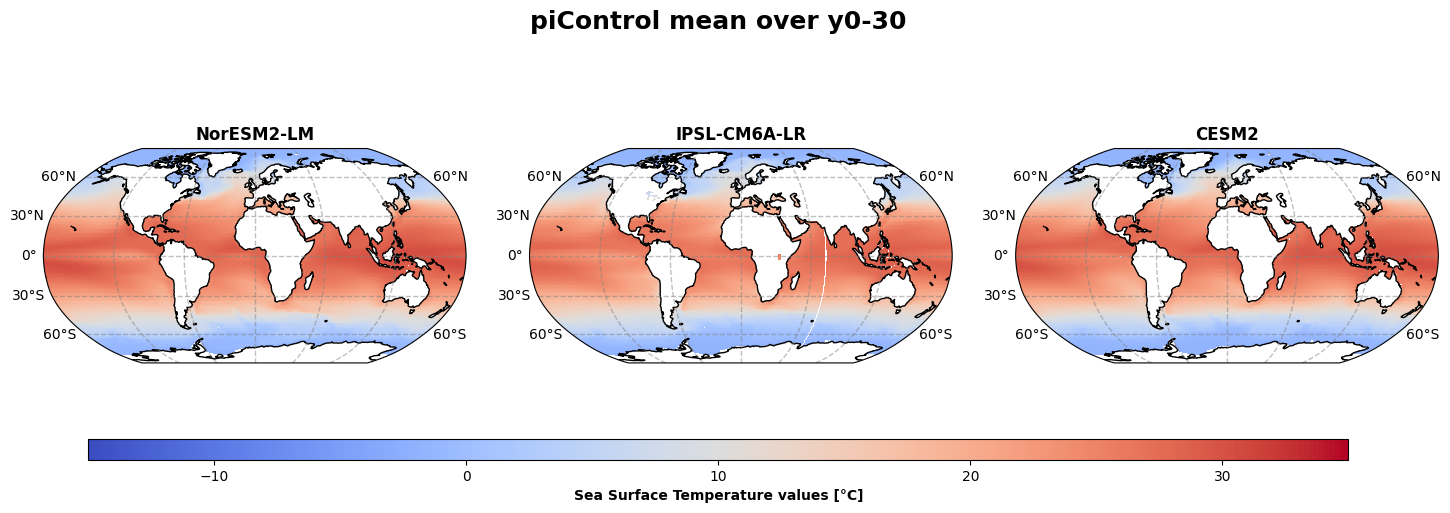

In [13]:
data_piControl_list = [tos_noresm2_piControl, tos_ipsl_piControl, tos_cesm2_piControl]
titles = ["NorESM2-LM", "IPSL-CM6A-LR", "CESM2"]

fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1, 1, 1])

# Copy and modify cmap
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="white")

for i, data_piControl in enumerate(data_piControl_list):

    lon = data_piControl.lon.values
    lat = data_piControl.lat.values
    data = data_piControl.values

    # ---- FIX: wrap longitudes into -180..180 ----
    lon_wrapped = (((lon + 180) % 360) - 180)
    sort_idx = np.argsort(lon_wrapped)
    lon_wrapped = lon_wrapped[sort_idx]
    data = data[:, sort_idx]    # reorder data columns to match longitudes

    # Plot
    ax = fig.add_subplot(gs[0, i], projection=ccrs.Robinson())

    im = ax.pcolormesh(
        lon_wrapped,
        lat,
        data,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=-15, vmax=35
    )

    ax.coastlines()
    ax.set_title(titles[i], fontweight='bold')

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False          # turn off top labels
    gl.right_labels = False        # turn off right labels
    gl.bottom_labels = False        # show lon labels
    gl.left_labels = True          # show lat labels

# ---- Horizontal colorbar spanning all panels ----
cbar_ax = fig.add_axes([0.15, 0.2, 0.7, 0.035])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Sea Surface Temperature values [°C]", fontweight='bold')

fig.suptitle("piControl mean over y0-30", fontsize=18, weight='bold', y=0.95)
plt.subplots_adjust(top=0.88, bottom=0.20, wspace=0.15)

plt.show()

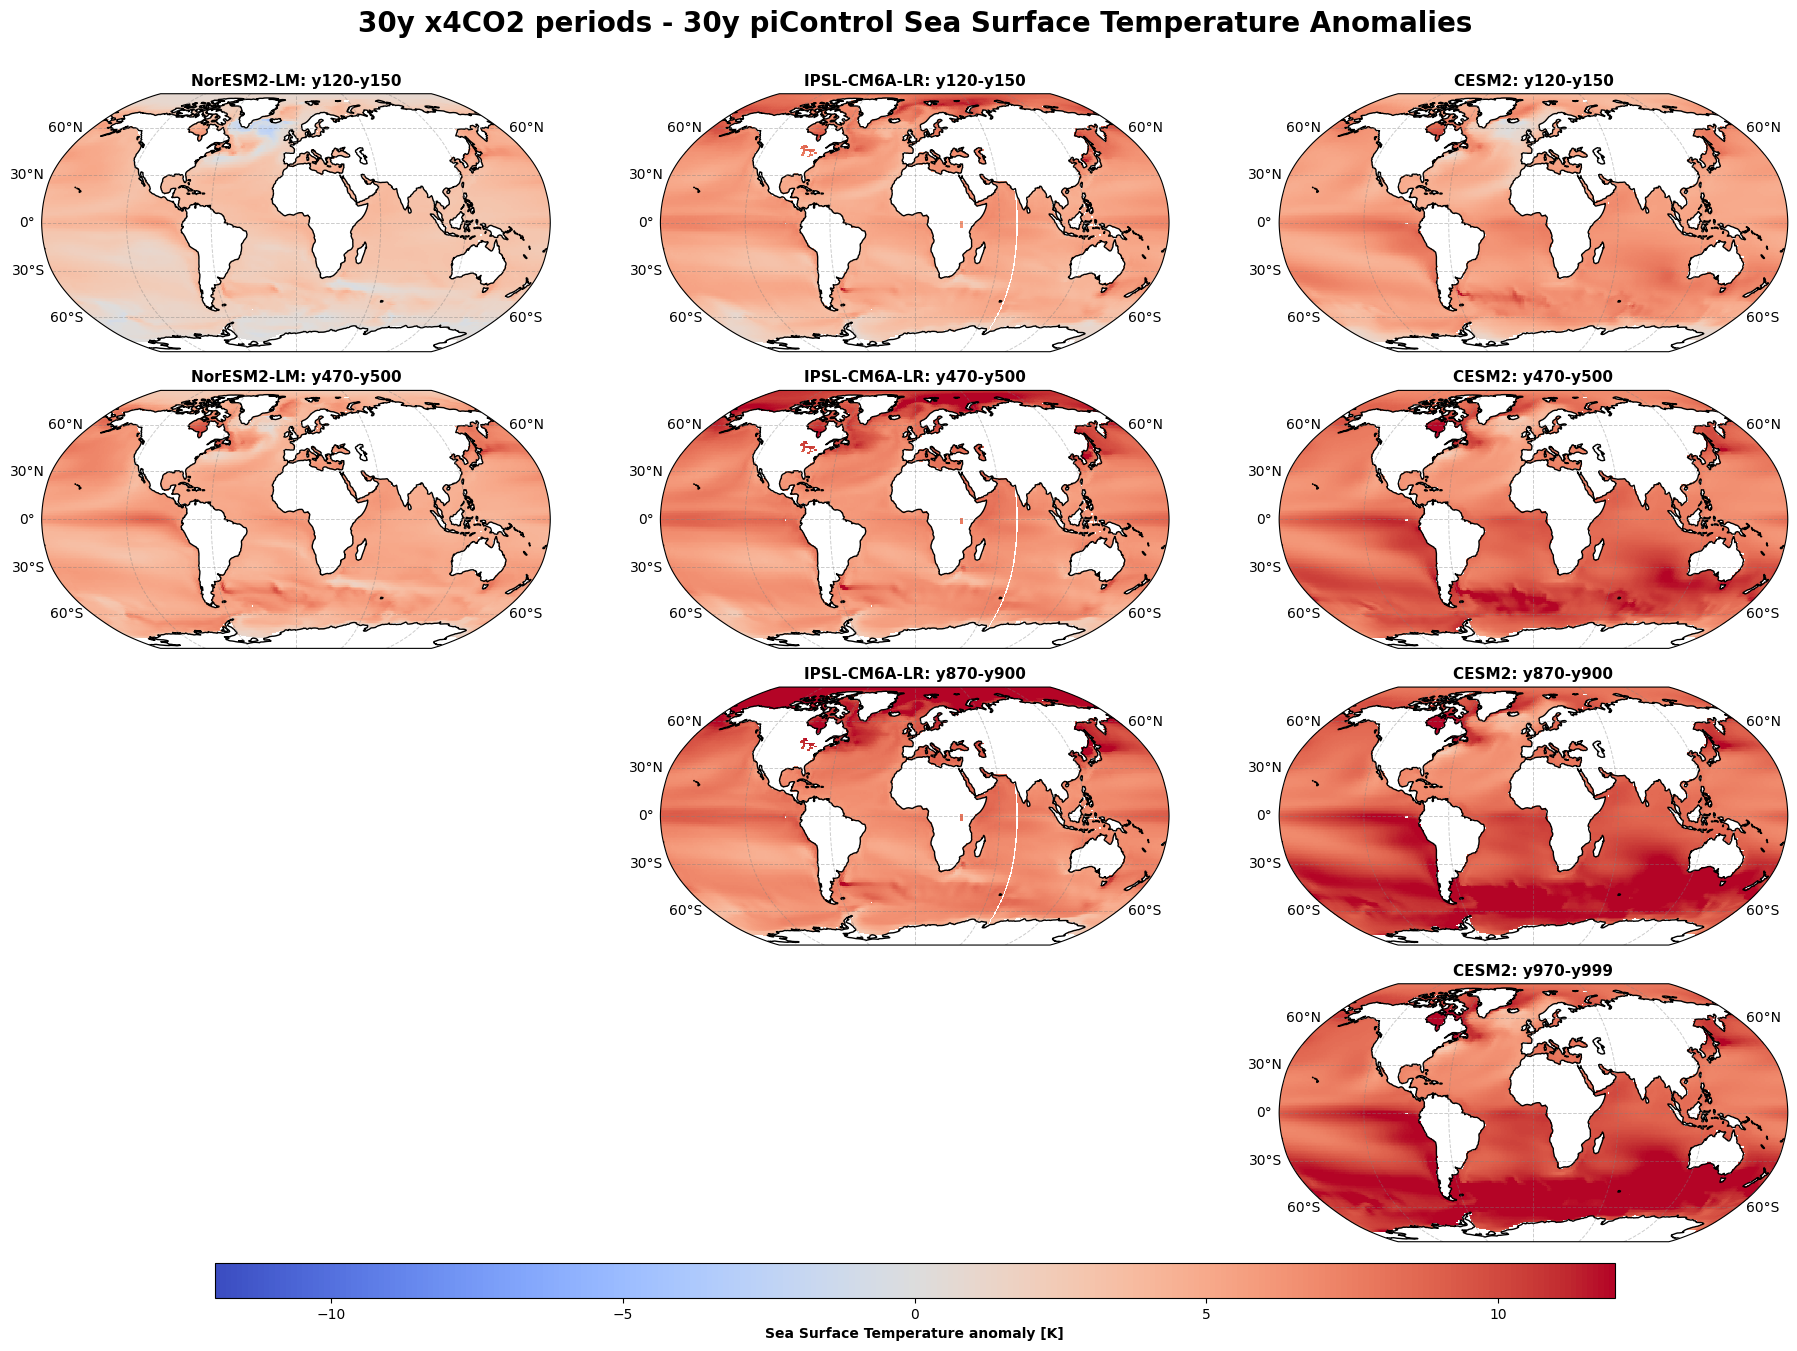

In [14]:
# ---- DATASETS ----

noresm_datasets = [
    (tos_noresm2_120_150 - tos_noresm2_piControl,  "NorESM2-LM: y120-y150"),
    (tos_noresm2_470_500 - tos_noresm2_piControl,  "NorESM2-LM: y470-y500"),
]

ipsl_datasets = [
    (tos_ipsl_120_150 - tos_ipsl_piControl, "IPSL-CM6A-LR: y120-y150"),
    (tos_ipsl_470_500 - tos_ipsl_piControl, "IPSL-CM6A-LR: y470-y500"),
    (tos_ipsl_870_900 - tos_ipsl_piControl, "IPSL-CM6A-LR: y870-y900"),
]

cesm_datasets = [
    (tos_cesm2_120_150 - tos_cesm2_piControl, "CESM2: y120-y150"),
    (tos_cesm2_470_500 - tos_cesm2_piControl, "CESM2: y470-y500"),
    (tos_cesm2_870_900 - tos_cesm2_piControl, "CESM2: y870-y900"),
    (tos_cesm2_970_999 - tos_cesm2_piControl, "CESM2: y970-y999"),
]

all_groups = [noresm_datasets, ipsl_datasets, cesm_datasets]

# Count how many rows needed for each column
col_rows = [len(noresm_datasets), len(ipsl_datasets), len(cesm_datasets)]
max_rows = max(col_rows)

# ---- FIGURE & COLORBAR ----

fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(
    nrows=max_rows, ncols=3,
    height_ratios=[1]*max_rows,   # equal row spacing
    width_ratios=[1, 1, 1]
)

cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="white")

# ---- FUNCTION: longitude wrapping ----
def wrap_lon(lon, data):
    lon_wrapped = (((lon + 180) % 360) - 180)
    s = np.argsort(lon_wrapped)
    return lon_wrapped[s], data[:, s]

# ---- PLOTTING LOOP ----

for col, group in enumerate(all_groups):          # 3 columns
    n_panels = len(group)
    if col == 0:  # NorESM2 column
        offset = 0              # top of column
    else:
        offset = (max_rows - n_panels) // 2   # center IPSL + CESM2       # center rows vertically

    for k, (data_anom, panel_title) in enumerate(group):

        lon = data_anom.lon.values
        lat = data_anom.lat.values
        data = data_anom.values

        # wrap longitudes to -180..180
        lon_w, data_w = wrap_lon(lon, data)

        row = offset + k                         # row placement inside column

        ax = fig.add_subplot(gs[row, col], projection=ccrs.Robinson())

        im = ax.pcolormesh(
            lon_w,
            lat,
            data_w,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            vmin=-12, vmax=12
        )

        ax.coastlines()
        ax.set_title(panel_title, fontsize=11, fontweight='bold')

        gl = ax.gridlines(
            crs=ccrs.PlateCarree(),
            draw_labels=True,
            linewidth=0.7,
            color='gray',
            alpha=0.4,
            linestyle='--'
        )
        gl.top_labels = False          # turn off top labels
        gl.right_labels = False        # turn off right labels
        gl.bottom_labels = False        # show lon labels
        gl.left_labels = True          # show lat labels
        

# ---- Horizontal colorbar ----
cbar_ax = fig.add_axes([0.15, 0.06, 0.7, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Sea Surface Temperature anomaly [K]", fontweight='bold')

# ---- Layout adjustments ----
fig.suptitle("30y x4CO2 periods - 30y piControl Sea Surface Temperature Anomalies", fontsize=20, weight='bold')

plt.subplots_adjust(
    left=0.05,
    right=0.95,
    top=0.92,
    bottom=0.10,
    wspace=0.10,
    hspace=0.15
)

plt.show()